In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# Configuration
DATA_PATH = '../data/dirty_heart_disease_renamed.csv'
TARGET = 'heart_disease_target'

In [3]:
# Data loading and inspection helpers
def load_data(path):
    return pd.read_csv(path)


def show_value_counts(df):
    for col in df.columns:
        print(col)
        print('=====================')
        print(df[col].value_counts())
        print('\n')

In [4]:
# Data cleaning helpers
def drop_missing_rows(df):
    df = df.dropna()
    return df.reset_index(drop=True)


def replace_question_marks(df):
    return df.replace('?', np.nan)


def clean_age(df):
    df['age'] = df['age'].replace({'54 years': '54'})
    df['age'] = pd.to_numeric(df['age'], errors='coerce')
    return df


def remove_age_outliers(df):
    Q1 = df['age'].quantile(0.25)
    Q3 = df['age'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df['age'] >= lower_bound) & (df['age'] <= upper_bound)]
    return df.reset_index(drop=True)


def clean_gender(df):
    df['gender'] = df['gender'].replace({
        '1': 'Male',
        1: 'Male',
        'M': 'Male',
        'F': 'Female'
    })
    most_common_gender = df['gender'].mode()[0]
    df['gender'] = df['gender'].replace('unknown', most_common_gender)
    return df


def clean_cholesterol(df):
    df['cholesterol'] = pd.to_numeric(df['cholesterol'], errors='coerce')
    df.loc[df['cholesterol'] < 0, 'cholesterol'] = np.nan
    df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())
    return df


def clean_resting_blood_pressure(df):
    df['resting_blood_pressure'] = pd.to_numeric(df['resting_blood_pressure'], errors='coerce')
    df['resting_blood_pressure'] = df['resting_blood_pressure'].fillna(df['resting_blood_pressure'].median())
    return df


def clean_st_depression(df):
    df['st_depression'] = df['st_depression'].astype(str).str.replace(',', '.')
    df['st_depression'] = pd.to_numeric(df['st_depression'], errors='coerce')
    df['st_depression'] = df['st_depression'].fillna(df['st_depression'].median())
    return df


def clean_thalassemia(df):
    most_frequent_thal = df['thalassemia'].mode()[0]
    df['thalassemia'] = df['thalassemia'].fillna(most_frequent_thal)
    df['thalassemia'] = pd.to_numeric(df['thalassemia'], errors='coerce')
    return df


def clean_data(df):
    df = drop_missing_rows(df)
    df = replace_question_marks(df)
    df = clean_age(df)
    df = remove_age_outliers(df)
    df = clean_gender(df)
    df = clean_cholesterol(df)
    df = clean_resting_blood_pressure(df)
    df = clean_st_depression(df)
    df = clean_thalassemia(df)
    return df

In [5]:
# Visualization helpers
def plot_key_relationships(df):
    # Create a 2x2 grid of plots showing the strongest relationships
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Heart disease rate by chest pain type
    sns.barplot(data=df, x='chest_pain_type', y=TARGET, ax=axes[0, 0], palette='viridis')
    axes[0, 0].set_title('Heart Disease Rate by Chest Pain Type')
    axes[0, 0].set_ylabel('Heart Disease Probability')

    # 2. Strong negative relationship between age and max heart rate
    sns.regplot(data=df, x='age', y='max_heart_rate', ax=axes[0, 1],
                scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
    axes[0, 1].set_title('Age vs Max Heart Rate (Strong Negative Correlation)')

    # 3. Max heart rate distribution by heart disease target
    sns.boxplot(data=df, x=TARGET, y='max_heart_rate', ax=axes[1, 0], palette='Set2')
    axes[1, 0].set_title('Max Heart Rate by Heart Disease Target')

    # 4. Heart disease rate by number of major vessels
    sns.barplot(data=df, x='num_major_vessels', y=TARGET, ax=axes[1, 1], palette='mako')
    axes[1, 1].set_title('Heart Disease Rate by Number of Major Vessels')

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_test, y_pred):
    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [6]:
# Modeling helpers:
# - encode categorical variables (e.g. gender) as numeric
# - split the data into 80% training and 20% testing
# - train a Random Forest model and evaluate its accuracy
def prepare_features(df):
    # Encode categorical variables as numeric
    df_encoded = pd.get_dummies(df, columns=['gender'], drop_first=True)

    # Define features (X) and target (y)
    X = df_encoded.drop(TARGET, axis=1)
    y = df_encoded[TARGET]
    return X, y


def split_data(X, y):
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


def train_model(X_train, y_train):
    model = RandomForestClassifier(random_state=42, n_estimators=100)
    model.fit(X_train, y_train)
    return model


def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Accuracy Score: {accuracy:.2f} ({accuracy*100:.1f}%)")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    plot_confusion_matrix(y_test, y_pred)

In [7]:
# Load the raw data
df = load_data(DATA_PATH)
df

,age,gender,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar_gt_120,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease_target
0,67,Female,2,133,344,1,0,159,1,0.9,2,0,2,1
1,57,Male,1,151,171,0,1,156,1,0.6,1,0,3,1
2,43,Female,0,102,132,0,2,180,0,"1,5",2,1,3,0
3,71,Female,3,158,NaN,0,0,179,0,0.7,1,1,3,1
4,36,Male,2,129,220,0,0,173,0,1.4,2,1,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,76,Male,2,122,380,0,1,147,1,0.7,2,2,3,1
303,39,1,0,109,291,0,0,165,0,0.5,2,0,1,0
304,300,Male,2,112,264,0,2,200,0,1.7,2,1,2,0
305,48,Male,1,148,-100,1,1,174,1,3.4,1,0,3,1


In [8]:
# Check column data types
df.dtypes

age                             str
gender                          str
chest_pain_type               int64
resting_blood_pressure          str
cholesterol                     str
fasting_blood_sugar_gt_120    int64
resting_ecg                   int64
max_heart_rate                int64
exercise_induced_angina       int64
st_depression                   str
st_slope                      int64
num_major_vessels             int64
thalassemia                     str
heart_disease_target          int64
dtype: object

In [9]:
# Check the raw data structure and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   age                         305 non-null    str  
 1   gender                      306 non-null    str  
 2   chest_pain_type             307 non-null    int64
 3   resting_blood_pressure      305 non-null    str  
 4   cholesterol                 306 non-null    str  
 5   fasting_blood_sugar_gt_120  307 non-null    int64
 6   resting_ecg                 307 non-null    int64
 7   max_heart_rate              307 non-null    int64
 8   exercise_induced_angina     307 non-null    int64
 9   st_depression               306 non-null    str  
 10  st_slope                    307 non-null    int64
 11  num_major_vessels           307 non-null    int64
 12  thalassemia                 306 non-null    str  
 13  heart_disease_target        307 non-null    int64
dtypes: int64(8), str(6)
m

In [10]:
# Apply the full cleaning pipeline
df = clean_data(df)

In [11]:
# Verify the cleaned data structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         295 non-null    float64
 1   gender                      295 non-null    str    
 2   chest_pain_type             295 non-null    int64  
 3   resting_blood_pressure      295 non-null    float64
 4   cholesterol                 295 non-null    float64
 5   fasting_blood_sugar_gt_120  295 non-null    int64  
 6   resting_ecg                 295 non-null    int64  
 7   max_heart_rate              295 non-null    int64  
 8   exercise_induced_angina     295 non-null    int64  
 9   st_depression               295 non-null    float64
 10  st_slope                    295 non-null    int64  
 11  num_major_vessels           295 non-null    int64  
 12  thalassemia                 295 non-null    int64  
 13  heart_disease_target        295 non-null    in

In [12]:
# Inspect value distribution of every column after cleaning
show_value_counts(df)

age
age
52.0    11
72.0    11
67.0    10
60.0    10
54.0     9
39.0     9
30.0     9
61.0     9
77.0     9
56.0     9
63.0     9
43.0     8
36.0     8
31.0     8
65.0     8
37.0     8
68.0     7
70.0     7
35.0     7
48.0     7
76.0     7
29.0     7
64.0     6
44.0     6
42.0     6
34.0     6
69.0     6
57.0     5
47.0     5
51.0     5
50.0     5
53.0     5
55.0     5
75.0     5
32.0     5
73.0     5
58.0     4
46.0     4
45.0     4
66.0     3
49.0     3
62.0     3
40.0     3
33.0     3
41.0     3
38.0     1
71.0     1
59.0     1
Name: count, dtype: int64


gender
gender
Male      207
Female     88
Name: count, dtype: int64


chest_pain_type
chest_pain_type
0    145
2     70
1     56
3     24
Name: count, dtype: int64


resting_blood_pressure
resting_blood_pressure
122.0    16
135.0    15
131.0    11
142.0     9
150.0     9
         ..
172.0     1
175.0     1
167.0     1
164.0     1
169.0     1
Name: count, Length: 71, dtype: int64


cholesterol
cholesterol
244.0    6
211.0    6
253.0 

In [13]:
# Correlation matrix of numeric columns
df.corr(numeric_only=True)

,age,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar_gt_120,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease_target
age,1.000000,-0.061284,-0.082255,0.050579,-0.051366,0.075226,-0.572267,0.061566,0.010982,-0.008497,-0.117509,0.111420,0.346274
chest_pain_type,-0.061284,1.000000,0.070421,0.058501,0.018182,-0.031942,0.074361,-0.028365,0.036817,0.056566,-0.059696,0.037655,0.447180
resting_blood_pressure,-0.082255,0.070421,1.000000,-0.064618,0.167748,0.041574,0.048673,-0.022700,-0.041676,-0.029811,-0.010386,-0.010894,-0.023110
cholesterol,0.050579,0.058501,-0.064618,1.000000,-0.010951,0.026969,-0.012021,-0.052629,-0.037832,-0.003976,-0.039433,-0.063444,0.110158
fasting_blood_sugar_gt_120,-0.051366,0.018182,0.167748,-0.010951,1.000000,-0.081326,-0.015769,0.055380,0.071737,-0.069624,-0.013496,-0.012796,0.049433
resting_ecg,0.075226,-0.031942,0.041574,0.026969,-0.081326,1.000000,-0.029109,-0.006050,0.053350,-0.050021,0.038512,-0.026221,0.015468
max_heart_rate,-0.572267,0.074361,0.048673,-0.012021,-0.015769,-0.029109,1.000000,-0.058890,-0.091764,0.063266,0.036981,-0.009526,-0.385732
exercise_induced_angina,0.061566,-0.028365,-0.022700,-0.052629,0.055380,-0.006050,-0.058890,1.000000,0.015989,0.032488,-0.070754,0.008879,0.146332
st_depression,0.010982,0.036817,-0.041676,-0.037832,0.071737,0.053350,-0.091764,0.015989,1.000000,-0.011458,-0.119099,0.045359,0.175888
st_slope,-0.008497,0.056566,-0.029811,-0.003976,-0.069624,-0.050021,0.063266,0.032488,-0.011458,1.000000,-0.063373,0.036087,-0.035773


/tmp/ipykernel_82/1516282769.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='chest_pain_type', y=TARGET, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_82/1516282769.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y='max_heart_rate', ax=axes[1, 0], palette='Set2')


/tmp/ipykernel_82/1516282769.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='num_major_vessels', y=TARGET, ax=axes[1, 1], palette='mako')


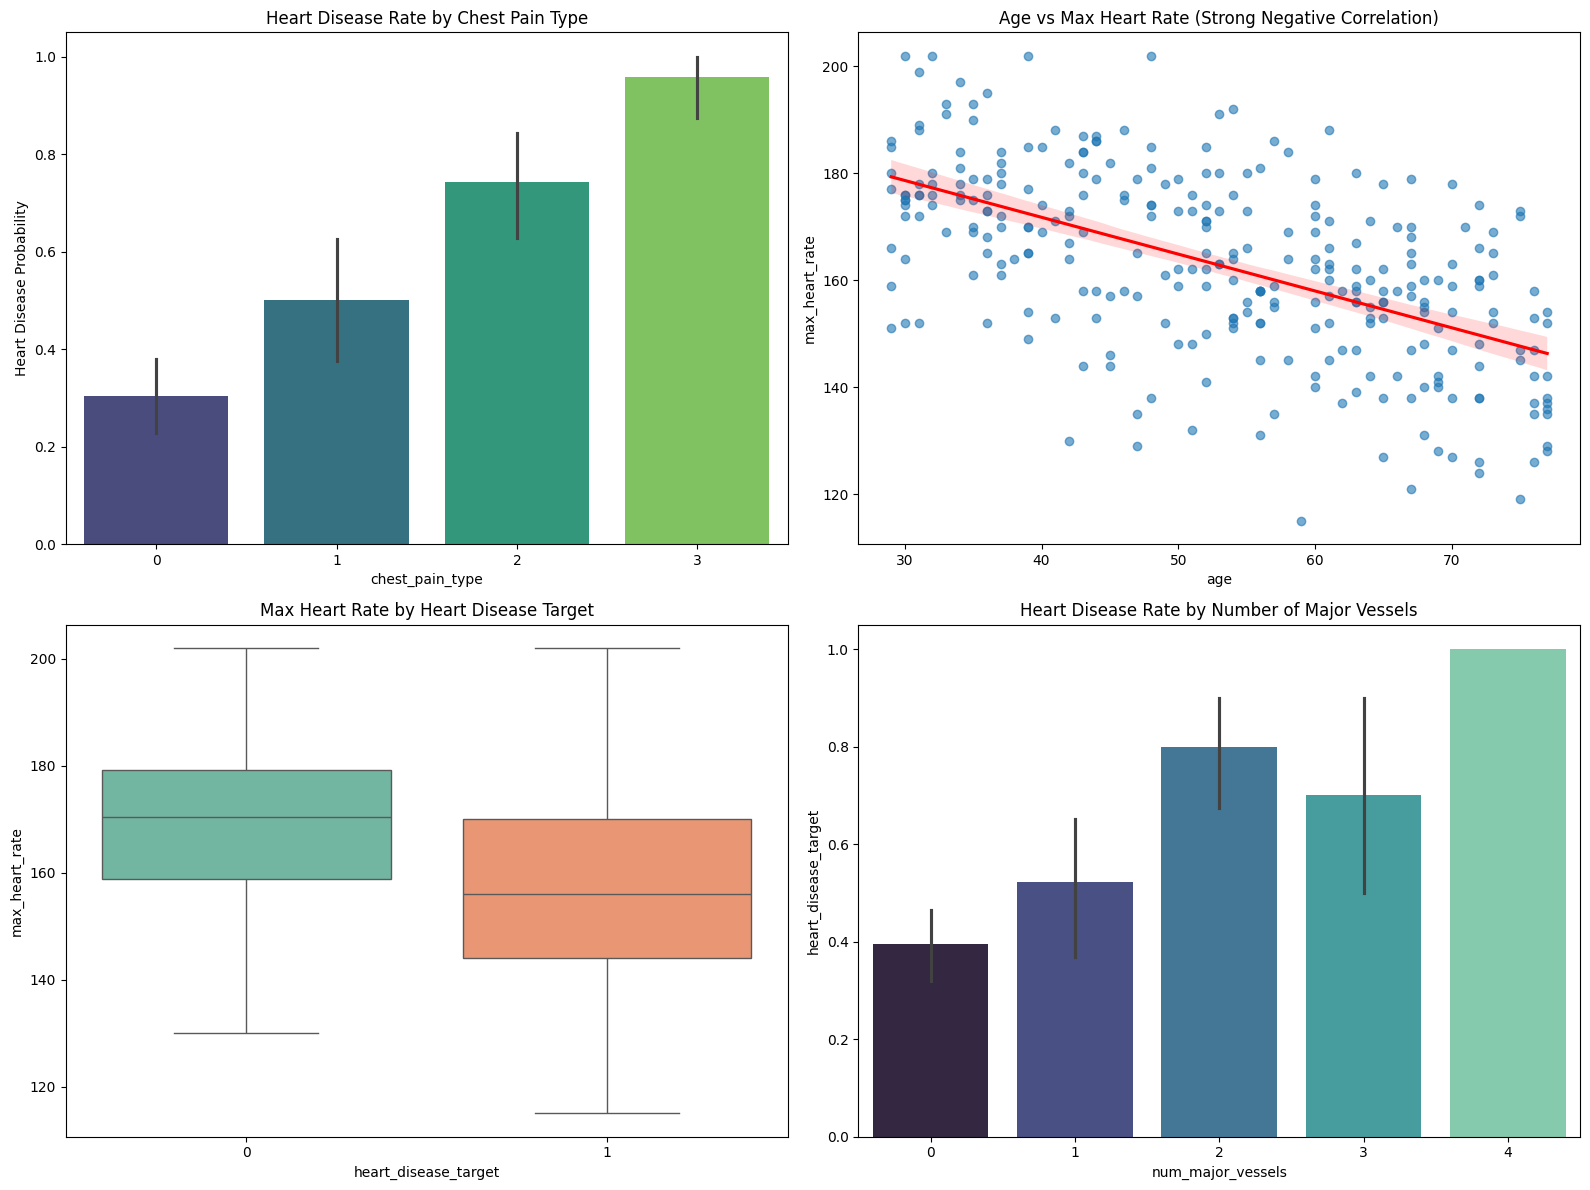

In [14]:
# Plot the strongest relationships
plot_key_relationships(df)

Accuracy Score: 0.80 (79.7%)

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        30
           1       0.79      0.79      0.79        29

    accuracy                           0.80        59
   macro avg       0.80      0.80      0.80        59
weighted avg       0.80      0.80      0.80        59



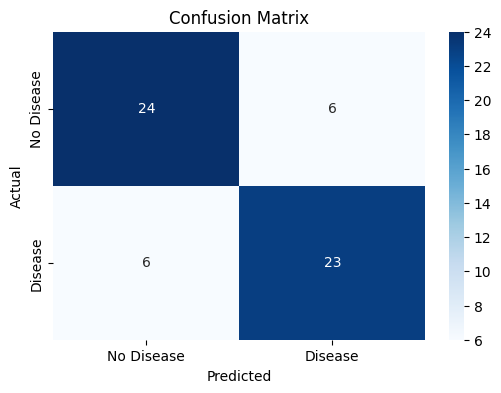

In [15]:
# Prepare features, split data, train the model and evaluate it
X, y = prepare_features(df)
X_train, X_test, y_train, y_test = split_data(X, y)

model = train_model(X_train, y_train)
evaluate_model(model, X_test, y_test)